# Security Anomaly Detection in Synthetic Enterprise Logs# Exploration Notebook

## 1. Introduction

This notebook presents the exploratory analysis, feature engineering validation, and statistical investigation of a synthetic enterprise security log dataset. The goal is to understand behavioral patterns, validate engineered features, and prepare the dataset for anomaly detection modeling.

## 2. Data Loading

In [91]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
from visualization.visualize import plot_distribution, plot_anomalies
from statistical_analysis.stats_analysis import detect_anomalies_iqr
from feature_engineering.feature_engineering import add_moving_averages
from feature_engineering.feature_engineering import add_time_window_aggregation
from statistical_analysis.stats_analysis import run_seasonal_decomposition, plot_seasonal_decomposition
from models.isolation_forest import run_isolation_forest
from models.lof import run_lof, save_lof_results
raw_df = pd.read_csv("../data/raw/raw_logs.csv")
attack_df = pd.read_csv("../data/raw/logs_with_attacks.csv")
df_svm = pd.read_csv("../data/processed/processed_logs_with_svm.csv")
df_auto = pd.read_csv("../data/processed/processed_logs_with_autoencoder.csv")
df_if = pd.read_csv("../data/processed/processed_logs_with_iforest.csv")


## 3. Dataset Inspection & Validation

### Objective
To validate the structure, realism, and analytical usefulness of the generated synthetic log dataset before proceeding to feature engineering and anomaly detection.

### Column by Column Inspection

The dataset contains the following fields:

In [68]:
print("Raw logs preview:")
display(raw_df.head())
print("Raw dataset shape:", raw_df.shape)

Raw logs preview:


,timestamp,user_id,username,department,role,privilege_level,source_ip,location,device_type,resource_accessed,action,login_success,failed_attempts,session_duration_min,is_attack,attack_type
0,2026-01-01 07:22:34,U002,donaldgarcia,HR,Staff,low,10.8.33.18,Berlin,Windows-Laptop,hr_portal,access,True,0,104,0,normal
1,2026-01-01 07:29:05,U007,lisa02,Finance,Analyst,medium,10.15.41.30,London,MacBook,security_dashboard,access,True,0,92,0,normal
2,2026-01-01 07:40:38,U007,lisa02,Finance,Analyst,medium,10.15.41.80,London,MacBook,finance_db,logout,True,0,50,0,normal
3,2026-01-01 07:54:26,U002,donaldgarcia,HR,Staff,low,10.8.33.111,Berlin,Windows-Laptop,security_dashboard,logout,True,0,37,0,normal
4,2026-01-01 08:07:53,U024,richard13,HR,Administrator,high,10.7.35.138,Toronto,MacBook,email_portal,logout,True,0,162,0,normal


Raw dataset shape: (5874, 16)



### Timestamp

- Timestamps are sequential and non-duplicated
- Events show realistic temporal progression
- No obvious inconsistencies or gaps

**Observation:**  
The dataset provides a strong temporal foundation for time-based analysis such as moving averages, aggregation, and anomaly detection.


### User Information

- Multiple users are present (e.g., `U002`, `donaldgarcia`)
- Departments (HR, IT, Finance) are well distributed
- Roles and privilege levels are logically assigned

**Observation:**  
The dataset supports behavioral profiling and role-based anomaly detection.

### Network & Device Context

- Source IP addresses vary across records
- Geographic locations are diverse
- Multiple device types are present

**Observation:**  
This variability enhances the ability to detect anomalies such as unusual login locations or suspicious device usage.

### Resource Access Patterns

- Systems accessed include:
  - `hr_portal`
  - `finance_db`
  - `admin_console`
  - `security_dashboard`
- Naming conventions reflect realistic enterprise environments

**Observation:**  
This enables modeling of:
- Privilege misuse
- Lateral movement across systems

### Action Types

- Actions include `login`, `access`, and `logout`
- Events are logically structured and consistent

**Observation:**  
The dataset accurately reflects real system activity logs, enabling meaningful sequence and behavioral analysis.


### Authentication Behavior

- `login_success` includes both True and False cases
- `failed_attempts` ranges between 0–2

**Observation:**  
This realistic distribution is critical for simulating:
- Credential stuffing
- Brute-force attacks
- Authentication anomalies

### Session Duration

- Values range from 0 to ~162 minutes
- Logical relationship observed:
  - Failed logins → short duration
  - Successful sessions → longer duration

**Observation:**  
Session modeling is highly realistic and suitable for anomaly detection based on session behavior.

### Ground Truth Labels

- `is_attack` is currently False for all records
- `attack_type` is empty

**Observation:**  
This represents a clean baseline dataset, suitable for controlled attack injection and evaluation.

## ⚠️ Minor Observations & Future Improvements

### Logout Event Duration

- Some logout events show relatively high session durations

**Interpretation:**  
This is not incorrect but can be refined for higher realism.

**Future Improvement:**
- Enforce shorter durations for logout-only events
- Separate session tracking from event logging if needed


## Overall Assessment

The dataset demonstrates:

- Strong structural integrity
- High realism across multiple dimensions
- Rich contextual features for behavioral analysis
- A solid baseline for anomaly detection experiments

## Conclusion

The generated dataset is well-suited for:
- Feature engineering
- Statistical analysis
- Temporal modeling
- Machine learning-based anomaly detection

No critical issues were identified, and the dataset is ready for the next stage of the pipeline.

## 4. Attack Distribution
This section checks how many records belong to each attack type.

Attack logs preview:


,timestamp,user_id,username,department,role,privilege_level,source_ip,location,device_type,resource_accessed,action,login_success,failed_attempts,session_duration_min,is_attack,attack_type,hour
0,2026-01-01 00:48:34,U017,perezantonio,Engineering,Administrator,high,185.220.101.70,New York,Windows-Laptop,git_server,login,False,7,0,1,credential_stuffing,0
1,2026-01-01 01:18:13,U035,josephbrennan,IT,Administrator,high,185.220.101.79,Berlin,MacBook,finance_db,login,False,5,2,1,credential_stuffing,1
2,2026-01-01 02:10:38,U056,jenniferross,HR,Administrator,high,185.220.101.24,Toronto,MacBook,hr_portal,login,False,14,2,1,credential_stuffing,2
3,2026-01-01 02:14:41,U022,robinsonwilliam,Finance,Administrator,high,172.16.7.30,Toronto,Windows-Laptop,admin_console,access,True,0,9,1,lateral_movement,2
4,2026-01-01 02:15:41,U022,robinsonwilliam,Finance,Administrator,high,172.16.1.78,Toronto,Windows-Laptop,file_share,access,True,0,20,1,lateral_movement,2


Attack-injected dataset shape: (6244, 17)
Attack types:
attack_type
normal                 5874
credential_stuffing     120
lateral_movement        100
privilege_misuse         80
abnormal_session         70
Name: count, dtype: int64


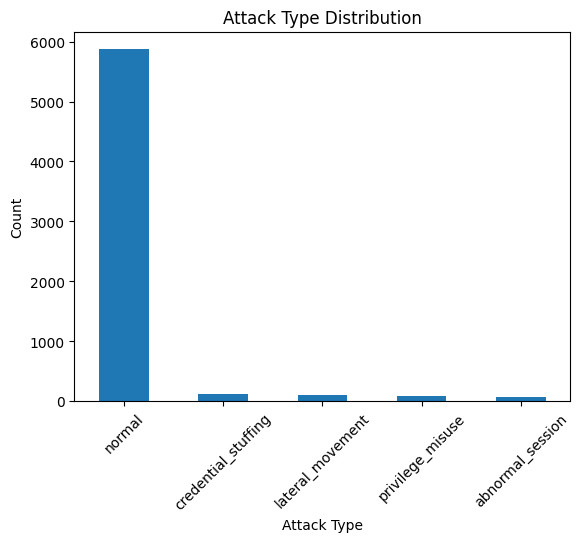

In [65]:
print("Attack logs preview:")
display(attack_df.head())
print("Attack-injected dataset shape:", attack_df.shape)
print("Attack types:")
attack_counts = attack_df["attack_type"].value_counts()
print(attack_counts)
attack_counts.plot(kind="bar")
plt.title("Attack Type Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Login Success vs Failure
This section checks the balance between successful and failed logins.

login_success
True     5686
False     558
Name: count, dtype: int64


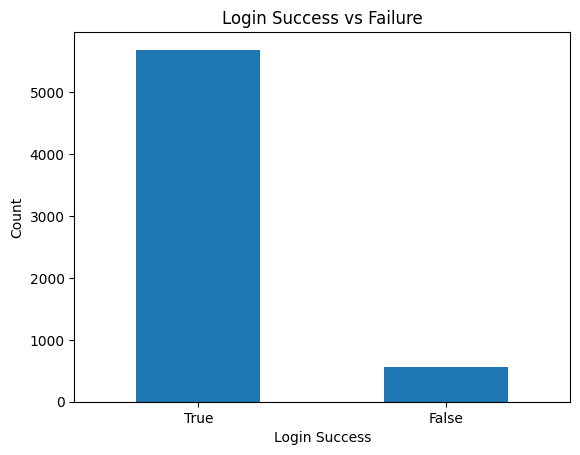

In [66]:
login_counts = attack_df["login_success"].value_counts()
print(login_counts)
login_counts.plot(kind="bar")
plt.title("Login Success vs Failure")
plt.xlabel("Login Success")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Session Duration Distribution
This section checks how session durations are distributed and whether there are unusual extremes.

count    6244.000000
mean       86.532671
std        62.183089
min         0.000000
25%        37.000000
50%        85.000000
75%       131.000000
max       716.000000
Name: session_duration_min, dtype: float64


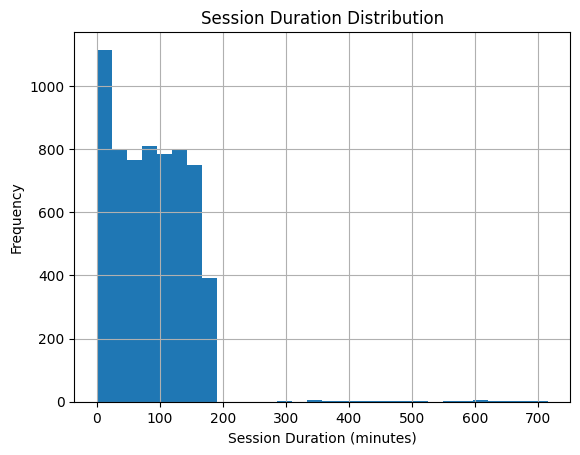

In [69]:
print(attack_df["session_duration_min"].describe())
attack_df["session_duration_min"].hist(bins=30)
plt.title("Session Duration Distribution")
plt.xlabel("Session Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

## User ID / Username Consistency Check
This section checks whether the same user_id is associated with multiple usernames.

In [17]:
user_username_check = attack_df.groupby("user_id")["username"].nunique()
mismatch_users = user_username_check[user_username_check > 1]

print("Number of user_id values linked to multiple usernames:", len(mismatch_users))
display(mismatch_users.head(10))

Number of user_id values linked to multiple usernames: 55


user_id
U001    6
U002    2
U003    3
U004    4
U005    5
U006    3
U007    4
U009    3
U011    4
U012    3
Name: username, dtype: int64

## Timestamp Inspection
This section checks whether attack events are clustering too heavily around certain hours.

hour
0      26
1      36
2      48
3      40
4      14
7      98
8     228
9     441
10    647
11    684
12    652
13    630
14    654
15    632
16    568
17    408
18    258
19    103
20     18
21      1
22     20
23     38
Name: count, dtype: int64


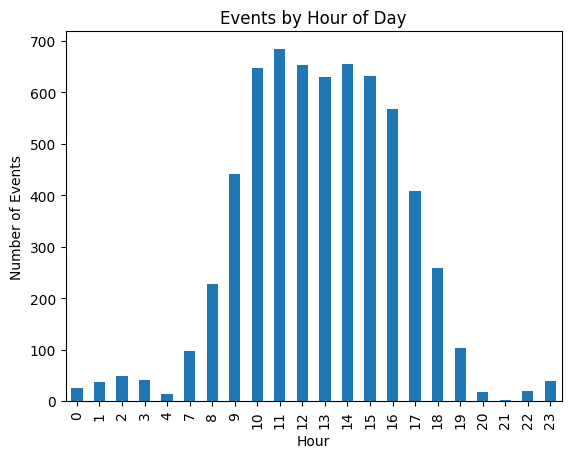

In [70]:
attack_df["timestamp"] = pd.to_datetime(attack_df["timestamp"])
attack_df["hour"] = attack_df["timestamp"].dt.hour

hour_counts = attack_df["hour"].value_counts().sort_index()
print(hour_counts)
hour_counts.plot(kind="bar")
plt.title("Events by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.show()

## Observed Issues & Improvements

### Observed Issues

   - Possible mismatch between `user_id` and `username` in some injected attack rows.
   - Attack timestamps may cluster heavily in off-hours, which is useful for anomaly realism but may need smoothing.
   - Some attack scenarios may still look too isolated rather than fully sequence-based.

### Planned Improvements

- Ensure `username` always matches the selected `user_id` during attack injection.
- Add more realistic temporal sequences for attack scenarios.
- Improve internal vs external IP separation for attack events.
- Add user-level baseline features for later feature engineering.
- Review whether session durations for certain actions need tighter realism constraints.

## 5. Feature Engineering Validation

In [20]:
processed_df = pd.read_csv("../data/processed/processed_logs.csv")
processed_df.head()
processed_df.columns
processed_df[["risk_score", "session_zscore", "failed_zscore", "session_deviation"]].describe()
processed_df["is_attack"].value_counts()
processed_df.groupby("attack_type")["risk_score"].mean().sort_values(ascending=False)

attack_type
credential_stuffing    4.943433
abnormal_session       0.998463
normal                 0.506274
lateral_movement       0.491466
privilege_misuse       0.436204
Name: risk_score, dtype: float64

### Feature Engineering Observations
- The engineered risk score strongly highlights credential stuffing behavior, with a much higher average score than all other event categories.
- Abnormal session events also show elevated risk compared to normal activity.
- Lateral movement and privilege misuse are not yet well separated from normal behavior using the current risk formulation.
- This suggests that the present risk score is more sensitive to authentication related anomalies than access-pattern anomalies.
- Additional features may be required later to better capture resource traversal behavior and privilege violations.

## 6. Statistical Analysis Observations

### Objective
To examine the distribution of key features and identify potential outliers.

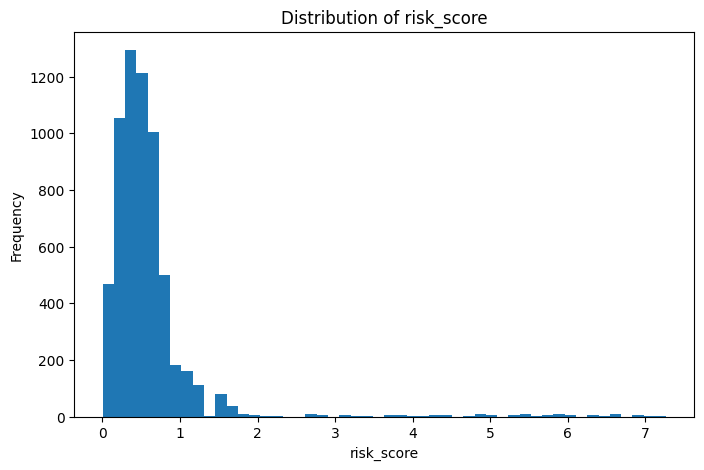

In [21]:
df = pd.read_csv("../data/processed/processed_logs_with_stats.csv")

plot_distribution(df, "risk_score", save=True)

## Observation:

- Distribution appears right skewed
- Majority of users have low to moderate risk scores
- Outliers exist at higher values → potential anomalies


## Risk Score Anomalies (IQR)

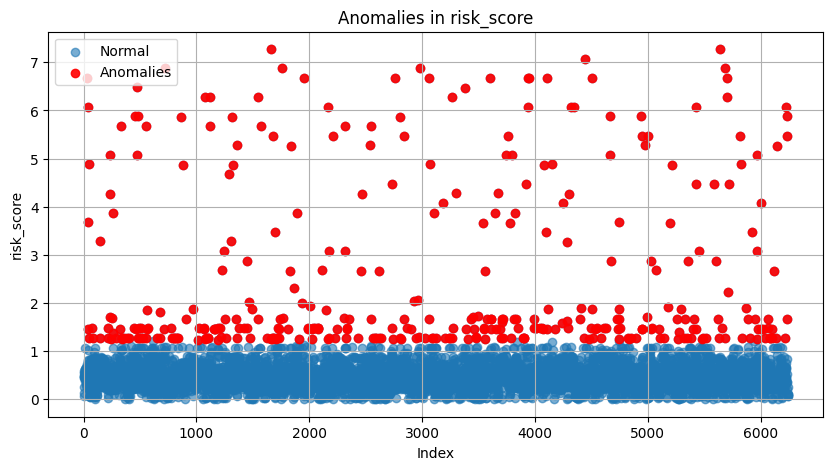

In [22]:
anomalies = detect_anomalies_iqr(df, "risk_score")
plot_anomalies(df, "risk_score", anomalies, save=True, filename="fig2_risk_score_anomalies.png")

## Observation:

- Clear separation between normal and anomalous points
- High-risk values correspond to injected attack scenarios
- IQR method captures extreme deviations effectively




## Session Duration Behavior

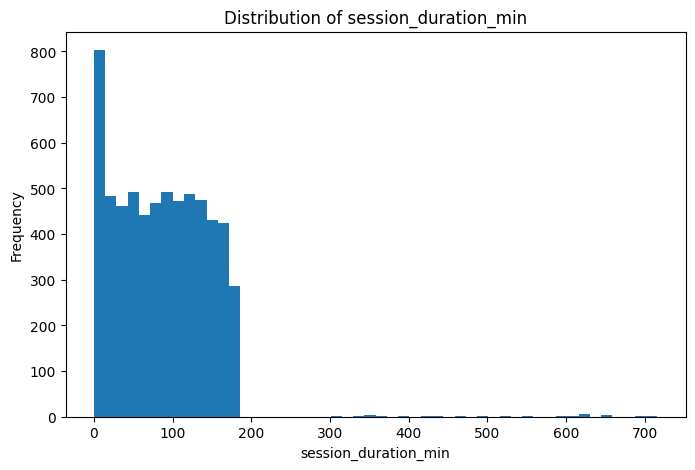

In [23]:
plot_distribution(df, "session_duration_min")

## Observation:

- Most sessions fall within normal working duration
- Long-duration sessions suggest persistence or misuse

## Login Frequency Patterns

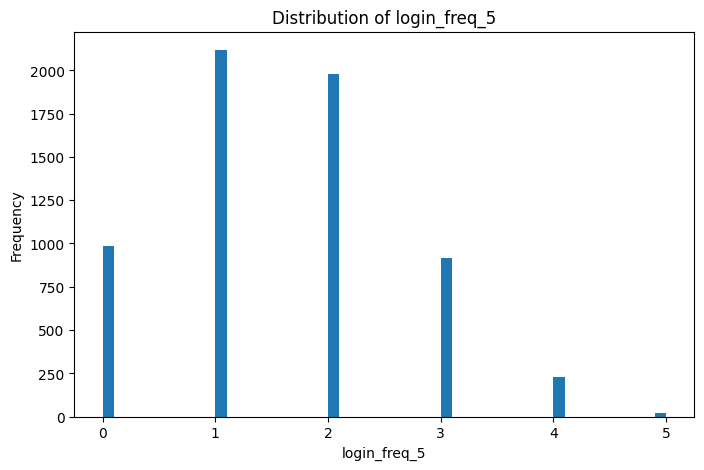

In [24]:
plot_distribution(df, "login_freq_5")

## Observation:

- Normal users show stable login frequency
- Sudden spikes indicate possible brute-force or automation	


## Moving Average Analysis (Temporal Smoothing)

### Objective
To analyze temporal patterns in the risk score by applying moving averages for smoothing short term fluctuations and highlighting sustained anomalous behavior.

### Methodology
- Applied rolling window smoothing (window = 5)
- Computed moving average of:
  - Risk score
  - Login frequency
- Derived deviation feature:
  - Difference between actual risk score and its moving average
- Sorted data chronologically to preserve temporal consistency

In [74]:
df = add_moving_averages(df, window=5)
df[['risk_score', 'risk_score_ma_5', 'risk_score_dev_5']].head(10)


,risk_score,risk_score_ma_5,risk_score_dev_5
0,0.133372,0.133372,0.000000
1,0.265240,0.199306,0.065934
2,0.072262,0.156958,-0.084696
3,0.487755,0.239657,0.248097
4,0.449958,0.281717,0.168241
5,0.597698,0.374583,0.223115
6,0.465829,0.414700,0.051129
7,0.536588,0.507566,0.029023
8,0.475478,0.505110,-0.029632
9,0.385043,0.492127,-0.107084


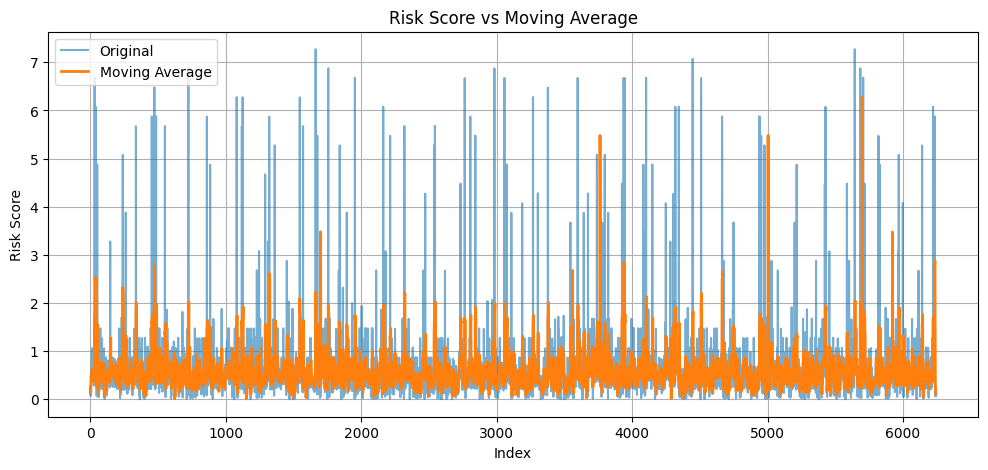

In [75]:
plt.figure(figsize=(12, 5))
plt.plot(df['risk_score'], label='Original', alpha=0.6)
plt.plot(df['risk_score_ma_5'], label='Moving Average', linewidth=2)

plt.title("Risk Score vs Moving Average")
plt.xlabel("Index")
plt.ylabel("Risk Score")
plt.legend()
plt.grid(True)

plt.show()

### Observations

- The moving average smooths short-term fluctuations, revealing the underlying trend in user behavior.
- Normal user activity appears stable with low variance over time.
- Sharp spikes in the original risk score indicate potential anomalous events such as:
  - Credential stuffing
  - Automated login attempts
- The deviation between actual and smoothed values highlights sudden behavioral changes more clearly.

### Insight

Moving averages improve anomaly detection by:
- Reducing noise in the signal
- Making abnormal spikes more distinguishable
- Providing a temporal baseline for comparison

This is particularly useful for detecting **burst-based attacks** and **short lived anomalies**.

### Limitation

- Moving averages may delay detection of very sudden attacks due to smoothing effect.
- Not sufficient alone for detecting complex attack patterns like lateral movement.

## Time-Window Aggregation

### Objective
To aggregate user activity into fixed temporal windows in order to capture short-duration attack bursts and summarize behavioral intensity over time.

### Method
User events were grouped by `user_id` and resampled into 5-minute windows. For each window, the following metrics were computed:
- Total login count
- Total failed login attempts
- Mean risk score

This transformation converts event-level logs into structured time series data suitable for temporal analysis.

### Implementation

In [28]:
df_agg = add_time_window_aggregation(df, window='5min').fillna(0)
df_agg.head()


,user_id,timestamp,login_count_5min,failed_attempts_5min,risk_score_mean_5min
0,U001,2026-01-01 09:05:00,0.0,0,0.133372
1,U001,2026-01-01 09:10:00,0.0,0,0.000000
2,U001,2026-01-01 09:15:00,0.0,0,0.000000
3,U001,2026-01-01 09:20:00,0.0,0,0.000000
4,U001,2026-01-01 09:25:00,0.0,0,0.000000


### Output Preview
The resulting dataset represents user activity aggregated into fixed 5-minute intervals, enabling clearer temporal pattern analysis.

### Observations
- Event-level logs are successfully transformed into a time-windowed representation of user activity.
- Periods of inactivity are explicitly represented, making temporal gaps and burst behavior more visible.
- Repeated events within short intervals are consolidated, allowing detection of high intensity activity bursts.
- The mean risk score provides a smoother and more interpretable signal compared to raw event-level fluctuations.

### Interpretation
Time-window aggregation enhances anomaly detection by highlighting concentrated activity patterns that may indicate automated attacks or credential stuffing. By summarizing behavior over time, it becomes easier to detect short lived anomalies that would otherwise be obscured in raw logs.

### Analytical Value
This step provides a strong temporal foundation for subsequent analysis and modeling by:
- Reducing noise from individual events
- Emphasizing behavioral trends over time
- Enabling integration with time-based anomaly detection techniques

### Limitations
- Aggregation may obscure fine grained event ordering within each time window.
- Windows with no activity may require handling (e.g., filling missing values) depending on downstream modeling needs.

## Seasonal Decomposition

### Objective
To separate temporal behavior into trend, seasonal, and residual components in order to better understand recurring patterns and irregular deviations in engineered features.

### Method
Seasonal decomposition was applied to the time indexed feature series after sorting by timestamp and resampling into uniform 5-minute intervals. The method separates each signal into:
- Trend component
- Seasonal component
- Residual component

This helps distinguish systematic temporal structure from abnormal fluctuations.

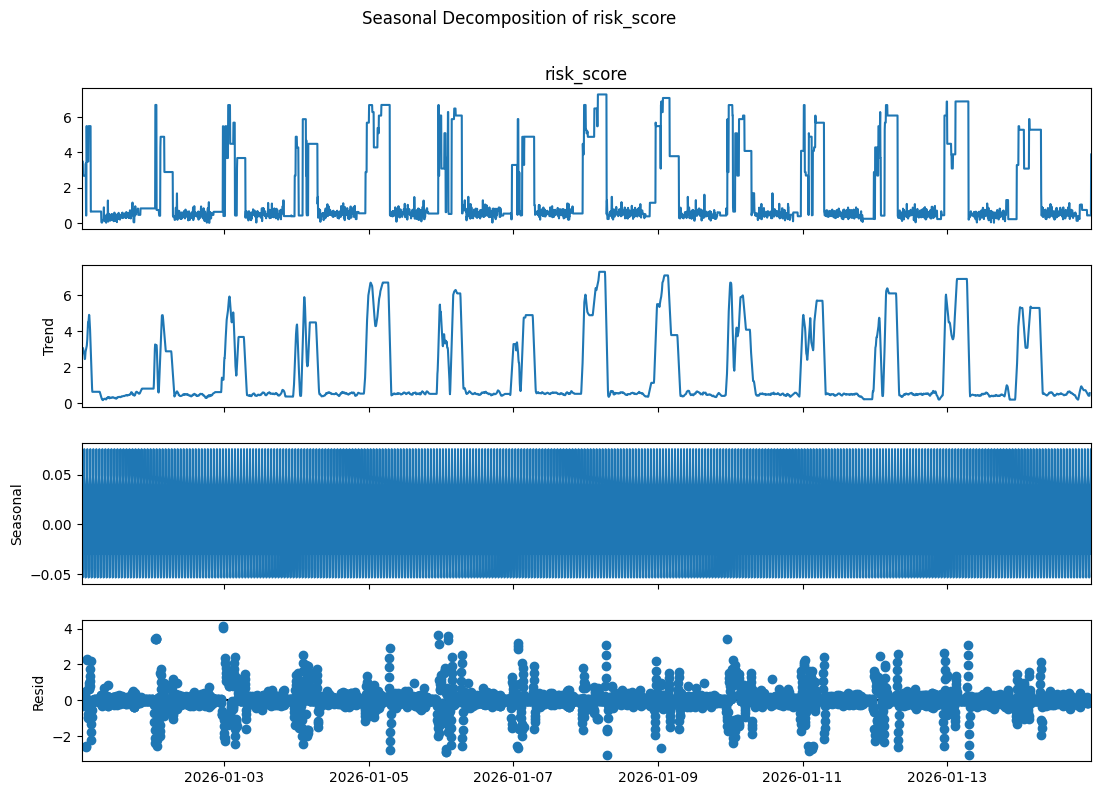

In [29]:
decomp = run_seasonal_decomposition(df, column="risk_score", period=12, model="additive")
plot_seasonal_decomposition(decomp, "risk_score")

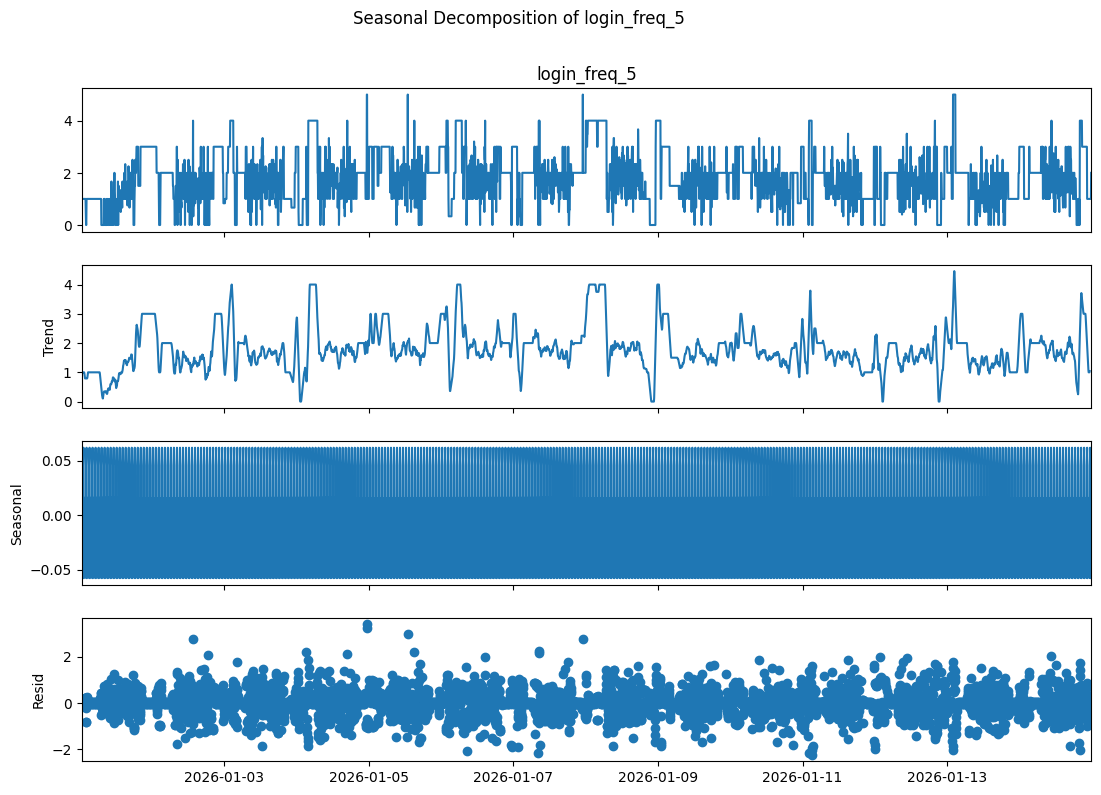

In [30]:
decomp_login = run_seasonal_decomposition(df, column="login_freq_5", period=12, model="additive")
plot_seasonal_decomposition(decomp_login, "login_freq_5")

### Observations

#### Login Frequency (`login_freq_5`)
- The original series shows irregular fluctuations with no strong long term upward or downward trend.
- The trend component remains relatively stable, indicating consistent user login behavior over time.
- The seasonal component is very weak and nearly flat, suggesting **no meaningful periodic pattern** in login frequency.
- The residual component captures most of the variability, indicating that fluctuations are largely random rather than cyclic.

#### Interpretation
Login behavior does not exhibit strong periodicity, implying that anomalies in login frequency are more likely due to irregular events (e.g., bursts or attacks) rather than predictable temporal patterns.

#### Risk Score (`risk_score`)
- The original signal shows **distinct sharp spikes**, representing high-risk events.
- The trend component clearly captures repeated increases in risk levels over time, suggesting structured bursts of suspicious activity.
- The seasonal component remains minimal, indicating **lack of consistent periodic behavior** in risk scores.
- The residual component contains scattered deviations, representing irregular anomalies not explained by trend or seasonality.

#### Interpretation
Risk score behavior is dominated by **episodic spikes rather than cyclical patterns**, which aligns with simulated attack scenarios such as credential stuffing or brute-force bursts.

### Key Insights
- Both features show **weak or negligible seasonality**, confirming that anomalies are not driven by periodic user behavior.
- The **trend component in risk_score** effectively captures attack bursts, making it a valuable signal for anomaly detection.
- The **residual component highlights unpredictable deviations**, which are strong candidates for anomaly detection.

### Analytical Value
Seasonal decomposition confirms that:
- The dataset is **event-driven rather than seasonally driven**
- Anomalies are better captured through:
  - spike detection
  - deviation from trend
  - statistical outlier methods

### Conclusion
Seasonal decomposition provides limited value for periodic pattern detection in this dataset, but it is highly useful for:
- isolating burst-based attack behavior (trend)
- identifying unexplained anomalies (residuals)

This reinforces the need to focus on **statistical and machine learning-based anomaly detection methods** rather than purely seasonal modeling.

## 7. Summary of Findings

- The dataset exhibits strong behavioral variability with realistic enterprise patterns.
- Feature engineering successfully captures temporal and behavioral anomalies.
- Statistical analysis reveals clear deviations in risk-related features.
- Temporal analysis confirms that anomalies are burst-driven rather than seasonal.

## 8. Isolation Forest Analysis

### Objective
To apply Isolation Forest as the first unsupervised machine learning model for anomaly detection and evaluate how effectively it identifies suspicious behavioral patterns in the engineered security log dataset.

### Method
Isolation Forest was applied to selected engineered numerical features that capture behavioral and statistical irregularities in user activity. The model was configured to identify a small proportion of records as anomalous based on their relative isolation in feature space.

The following features were used as model inputs:
- `risk_score`
- `session_duration_min`
- `login_freq_5`
- `failed_attempts_rolling`
- `session_zscore`
- `failed_zscore`

The model generated:
- a binary anomaly output (`iforest_anomaly`)
- a raw prediction label (`iforest_label`)
- an anomaly score (`iforest_score`)



### Isolation Forest Dataset Preview
The Isolation Forest model was applied to the processed feature dataset after feature engineering and statistical analysis.

In [92]:
df_if.head()

,timestamp,user_id,username,department,role,privilege_level,source_ip,location,device_type,resource_accessed,...,session_zscore,failed_zscore,session_deviation,risk_score,session_duration_min_zscore,login_freq_5_zscore,risk_score_zscore,iforest_label,iforest_anomaly,iforest_score
0,2026-01-01 09:05:41,U001,johnsonjoshua,HR,Analyst,low,10.5.48.47,New York,Windows-Laptop,email_portal,...,0.666859,-0.198587,46.931373,0.133372,0.666859,-1.492579,-0.656367,1,0,0.128048
1,2026-01-01 11:53:29,U001,johnsonjoshua,HR,Analyst,low,10.5.48.137,New York,Windows-Laptop,email_portal,...,1.326202,-0.198587,87.931373,0.265240,1.326202,-1.492579,-0.469247,1,0,0.087179
2,2026-01-01 12:17:27,U001,johnsonjoshua,HR,Analyst,low,10.5.48.87,New York,Windows-Laptop,git_server,...,0.361309,-0.198587,27.931373,0.072262,0.361309,-1.492579,-0.743081,1,0,0.128730
3,2026-01-01 12:41:04,U001,johnsonjoshua,HR,Analyst,low,10.5.48.11,New York,Windows-Laptop,git_server,...,1.438773,-0.198587,94.931373,0.487755,1.438773,-0.543820,-0.153502,1,0,0.116212
4,2026-01-01 12:53:01,U001,johnsonjoshua,HR,Analyst,low,10.5.48.33,New York,Windows-Laptop,hr_portal,...,-0.249789,-0.198587,-10.068627,0.449958,-0.249789,0.404940,-0.207135,1,0,0.183082


### Prediction Summary
The first step is to inspect how many records were classified as normal versus anomalous by the model.

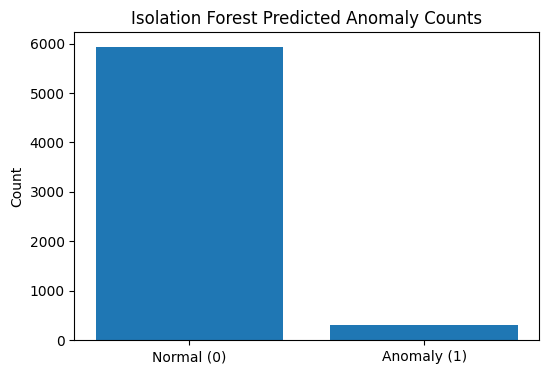

iforest_anomaly
0    5931
1     313
Name: count, dtype: int64


In [32]:
counts = df_if["iforest_anomaly"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Normal (0)", "Anomaly (1)"], counts.values)
plt.title("Isolation Forest Predicted Anomaly Counts")
plt.ylabel("Count")
plt.show()

print(counts)

### Ground Truth Comparison
Although the model is unsupervised and does not use attack labels during training, the synthetic ground truth labels are used here for post hoc evaluation.

iforest_anomaly     0    1
is_attack                 
0                5714  160
1                 217  153


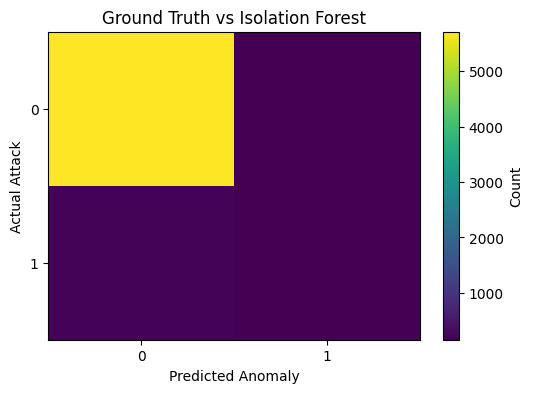

In [33]:
comparison = pd.crosstab(df_if["is_attack"], df_if["iforest_anomaly"])
print(comparison)

plt.figure(figsize=(6,4))
plt.imshow(comparison, aspect="auto")
plt.title("Ground Truth vs Isolation Forest")
plt.xlabel("Predicted Anomaly")
plt.ylabel("Actual Attack")
plt.xticks([0,1], ["0", "1"])
plt.yticks([0,1], ["0", "1"])
plt.colorbar(label="Count")
plt.show()

### Isolation Forest Score Distribution
The anomaly score distribution helps show how the model separates more normal observations from more abnormal ones. Lower scores indicate stronger anomaly likelihood.

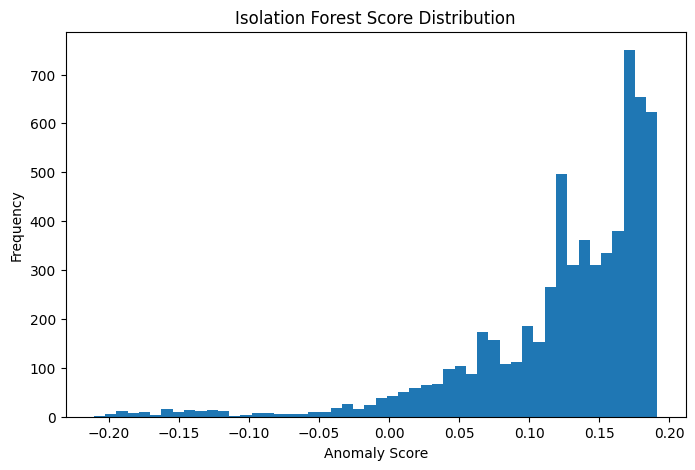

In [34]:
plt.figure(figsize=(8,5))
plt.hist(df_if["iforest_score"], bins=50)
plt.title("Isolation Forest Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.show()

### Feature Space Visualization
To understand how the model behaves in feature space, predictions are visualized using `risk_score` and `session_duration_min`.

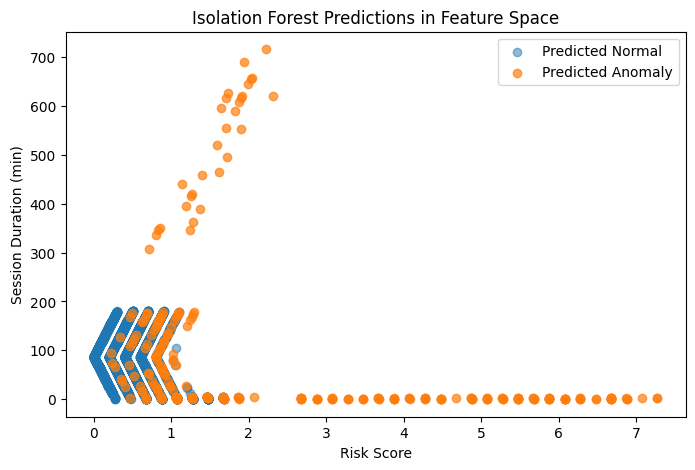

In [35]:
plt.figure(figsize=(8,5))

normal = df_if[df_if["iforest_anomaly"] == 0]
anomaly = df_if[df_if["iforest_anomaly"] == 1]

plt.scatter(normal["risk_score"], normal["session_duration_min"], alpha=0.5, label="Predicted Normal")
plt.scatter(anomaly["risk_score"], anomaly["session_duration_min"], alpha=0.7, label="Predicted Anomaly")

plt.title("Isolation Forest Predictions in Feature Space")
plt.xlabel("Risk Score")
plt.ylabel("Session Duration (min)")
plt.legend()
plt.show()

### Temporal Spread of Predicted Anomalies
The predicted anomalies are also visualized across the dataset index to inspect whether the model highlights high-risk spikes consistently.

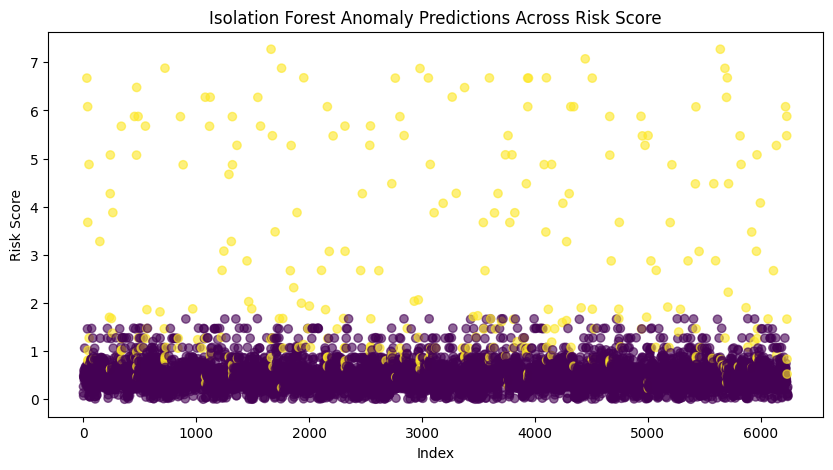

In [36]:
plt.figure(figsize=(10,5))

plt.scatter(df_if.index, df_if["risk_score"], c=df_if["iforest_anomaly"], alpha=0.6)
plt.title("Isolation Forest Anomaly Predictions Across Risk Score")
plt.xlabel("Index")
plt.ylabel("Risk Score")
plt.show()

### Observations

- The Isolation Forest model classified **5931 records as normal** and **313 records as anomalous**.
- Comparison with ground truth shows that the model correctly identified **153 true attack records** as anomalies.
- However, **217 attack records were missed**, indicating that not all injected attacks were well separated by the current feature set.
- The model also produced **160 false positives**, meaning some normal records were incorrectly flagged as suspicious.
- The anomaly score distribution suggests that most records are concentrated in the more normal score region, while a smaller subset lies in the lower-score abnormal region.
- In feature space, predicted anomalies are concentrated around:
  - unusually high risk scores
  - extremely short session durations
  - unusually long session durations
- This indicates that Isolation Forest is particularly sensitive to strong behavioral deviations, especially those associated with abnormal session behavior and elevated risk signals.

### Interpretation

The model demonstrates **moderate anomaly detection capability**. It is able to identify a meaningful subset of injected attacks, especially more extreme behaviors, but it still misses a substantial number of attack records and produces some false alarms.

The results suggest that the current engineered features are useful for anomaly detection, but may still be more effective for obvious anomalies than for more subtle attack patterns such as privilege misuse or lateral movement.

### Analytical Value

This model serves as the first machine learning-based anomaly detector in the pipeline and provides a useful benchmark for comparison with:
- Local Outlier Factor (LOF)
- One-Class SVM
- Autoencoder

It also confirms that the engineered feature space contains enough behavioral signal for unsupervised learning to identify suspicious patterns.

### Limitation

- The model appears more effective at capturing extreme anomalies than subtle contextual deviations.
- Some attack categories may require more specialized features for better separation.
- Further comparison with other models is necessary before drawing conclusions about the best-performing detection approach.

### Conclusion
Isolation Forest provides a strong first unsupervised baseline for anomaly detection in the synthetic enterprise security log dataset. Its performance indicates that the engineered behavioral and statistical features are informative, while also showing that additional refinement and multi-model comparison are necessary for improved detection coverage.

## 9. Local Outlier Factor (LOF) Analysis

### Objective
To evaluate the effectiveness of Local Outlier Factor (LOF) in detecting anomalous user behavior within the synthetic enterprise security dataset.

### Method
LOF is a density-based anomaly detection method that identifies observations that have significantly lower density compared to their local neighborhood. Unlike Isolation Forest, which isolates global outliers, LOF focuses on detecting local deviations in behavior.

The model was applied to the following engineered features:
- Risk score
- Session duration
- Login frequency (rolling window)
- Failed attempts (rolling)
- Session z-score
- Failed attempts z-score

The model outputs:
- `lof_anomaly` (0 = normal, 1 = anomaly)
- `lof_score` (local density deviation score)

### LOF dataset preview 

In [37]:
df_lof = run_lof(
    df,
    feature_cols=[
        "risk_score",
        "session_duration_min",
        "login_freq_5",
        "failed_attempts_rolling",
        "session_zscore",
        "failed_zscore"
    ],
    n_neighbors=20,
    contamination=0.05
)

df_lof.head()

,timestamp,user_id,username,department,role,privilege_level,source_ip,location,device_type,resource_accessed,...,risk_score,session_duration_min_zscore,login_freq_5_zscore,risk_score_zscore,risk_score_ma_5,login_freq_ma_5,risk_score_dev_5,lof_label,lof_anomaly,lof_score
0,2026-01-01 09:05:41,U001,johnsonjoshua,HR,Analyst,low,10.5.48.47,New York,Windows-Laptop,email_portal,...,0.133372,0.666859,-1.492579,-0.656367,0.133372,0.00,0.000000,1,0,-1.057999
1,2026-01-01 11:53:29,U001,johnsonjoshua,HR,Analyst,low,10.5.48.137,New York,Windows-Laptop,email_portal,...,0.265240,1.326202,-1.492579,-0.469247,0.199306,0.00,0.065934,1,0,-1.140975
2,2026-01-01 12:17:27,U001,johnsonjoshua,HR,Analyst,low,10.5.48.87,New York,Windows-Laptop,git_server,...,0.072262,0.361309,-1.492579,-0.743081,0.156958,0.00,-0.084696,1,0,-1.116689
3,2026-01-01 12:41:04,U001,johnsonjoshua,HR,Analyst,low,10.5.48.11,New York,Windows-Laptop,git_server,...,0.487755,1.438773,-0.543820,-0.153502,0.239657,0.25,0.248097,1,0,-0.999164
4,2026-01-01 12:53:01,U001,johnsonjoshua,HR,Analyst,low,10.5.48.33,New York,Windows-Laptop,hr_portal,...,0.449958,-0.249789,0.404940,-0.207135,0.281717,0.60,0.168241,1,0,-0.997671


### Prediction Summary
This section shows how many records were classified as normal versus anomalous by the LOF model.

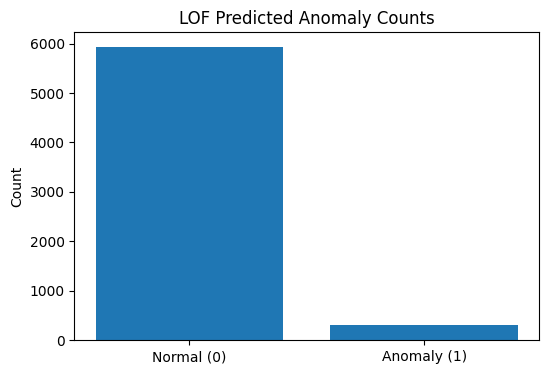

lof_anomaly
0    5931
1     313
Name: count, dtype: int64


In [44]:
counts = df_lof["lof_anomaly"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Normal (0)", "Anomaly (1)"], counts.values)
plt.title("LOF Predicted Anomaly Counts")
plt.ylabel("Count")
plt.show()

print(counts)

### Ground Truth vs LOF
Although LOF is unsupervised, synthetic attack labels are used here for evaluation purposes.

lof_anomaly     0    1
is_attack             
0            5584  290
1             347   23


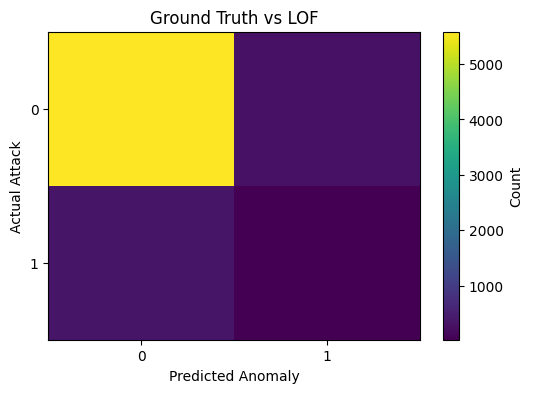

In [45]:
comparison = pd.crosstab(df_lof["is_attack"], df_lof["lof_anomaly"])
print(comparison)

plt.figure(figsize=(6,4))
plt.imshow(comparison, aspect="auto")
plt.title("Ground Truth vs LOF")
plt.xlabel("Predicted Anomaly")
plt.ylabel("Actual Attack")
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])
plt.colorbar(label="Count")
plt.show()

### Observations

From the confusion matrix:

- True Negatives (Normal correctly identified): 5584  
- False Positives (Normal flagged as anomaly): 290  
- False Negatives (Missed attacks): 347  
- True Positives (Correctly detected attacks): 23  

Key insights:

- LOF detected significantly fewer true attacks (23) compared to Isolation Forest.
- A large number of attacks (347) were not detected.
- The model produced a moderate number of false positives (290), indicating sensitivity to local variations.

### Interpretation

The results indicate that LOF struggles to effectively detect the injected attack patterns in this dataset. This is likely because:

- Many attacks manifest as global deviations (e.g., extreme risk scores), which LOF is less suited for.
- LOF focuses on local density, making it more sensitive to subtle variations rather than strong outliers.
- Attack patterns such as credential stuffing and abnormal session duration are more globally distinguishable than locally irregular.

Overall, LOF underperforms compared to Isolation Forest in this context.

### LOF Score Distribution
The distribution of LOF scores provides insight into how the model differentiates between normal and anomalous behavior.

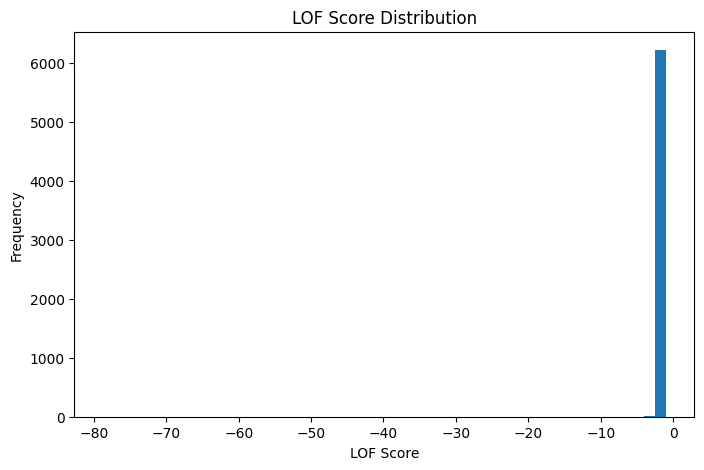

In [49]:
plt.figure(figsize=(8,5))
plt.hist(df_lof["lof_score"], bins=50)
plt.title("LOF Score Distribution")
plt.xlabel("LOF Score")
plt.ylabel("Frequency")
plt.show()

### Feature Space Visualization
This plot shows how LOF classifies observations in feature space using risk score and session duration.

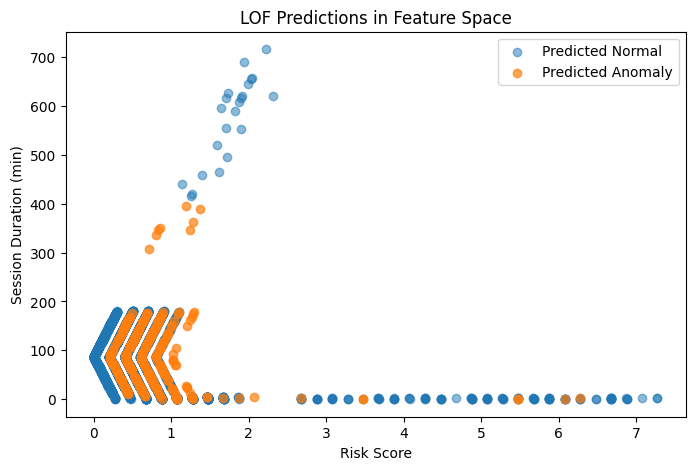

In [50]:
plt.figure(figsize=(8,5))

normal = df_lof[df_lof["lof_anomaly"] == 0]
anomaly = df_lof[df_lof["lof_anomaly"] == 1]

plt.scatter(
    normal["risk_score"],
    normal["session_duration_min"],
    alpha=0.5,
    label="Predicted Normal"
)

plt.scatter(
    anomaly["risk_score"],
    anomaly["session_duration_min"],
    alpha=0.7,
    label="Predicted Anomaly"
)

plt.title("LOF Predictions in Feature Space")
plt.xlabel("Risk Score")
plt.ylabel("Session Duration (min)")
plt.legend()
plt.show()

### Temporal Distribution of Anomalies
This visualization shows how LOF anomaly predictions are distributed across the dataset.

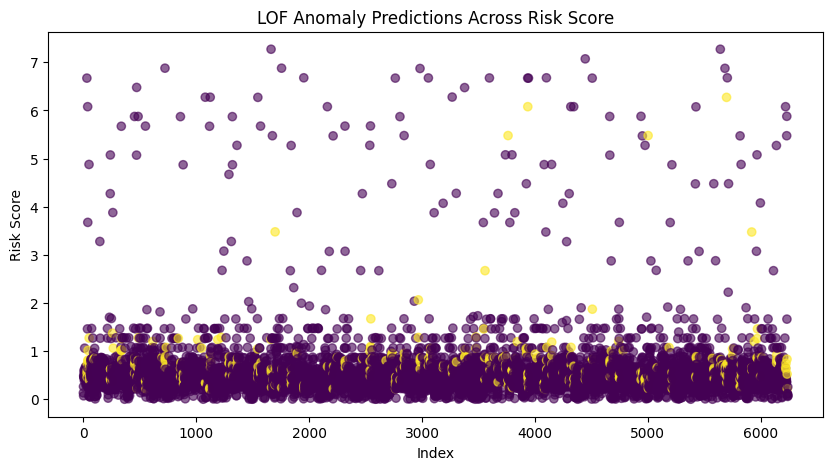

In [51]:
plt.figure(figsize=(10,5))

plt.scatter(
    df_lof.index,
    df_lof["risk_score"],
    c=df_lof["lof_anomaly"],
    alpha=0.6
)

plt.title("LOF Anomaly Predictions Across Risk Score")
plt.xlabel("Index")
plt.ylabel("Risk Score")
plt.show()

### Conclusion

The Local Outlier Factor model provides a density-based perspective on anomaly detection but shows limited effectiveness in detecting the simulated attack patterns in this dataset.

Compared to Isolation Forest:
- LOF detects fewer true anomalies
- Misses a larger portion of attack events
- Produces moderate false positives

This suggests that:
- The anomalies in this dataset are better represented as global deviations rather than local density irregularities
- LOF may be more suitable for datasets where anomalies are subtle and locally defined

### Role in Pipeline

LOF serves as a comparative baseline model that highlights the importance of selecting appropriate anomaly detection techniques based on the nature of the data.

## 10. One-Class SVM Analysis

### Objective
To evaluate the effectiveness of One-Class Support Vector Machine (One-Class SVM) in detecting anomalous behavioral patterns within the synthetic enterprise security dataset.

### Method
One-Class SVM was applied to the engineered numerical feature space to learn the boundary of normal behavior and identify observations that fall outside that boundary as anomalies.

The model was applied to the following features:
- `risk_score`
- `session_duration_min`
- `login_freq_5`
- `failed_attempts_rolling`
- `session_zscore`
- `failed_zscore`

The model generated:
- `svm_anomaly` (0 = normal, 1 = anomaly)
- `svm_label`
- `svm_score`

### One-Class SVM dataset output preview

In [ ]:
df_svm.head()


,timestamp,user_id,username,department,role,privilege_level,source_ip,location,device_type,resource_accessed,...,session_zscore,failed_zscore,session_deviation,risk_score,session_duration_min_zscore,login_freq_5_zscore,risk_score_zscore,svm_label,svm_anomaly,svm_score
0,2026-01-01 09:05:41,U001,johnsonjoshua,HR,Analyst,low,10.5.48.47,New York,Windows-Laptop,email_portal,...,0.666859,-0.198587,46.931373,0.133372,0.666859,-1.492579,-0.656367,1,0,3.545365
1,2026-01-01 11:53:29,U001,johnsonjoshua,HR,Analyst,low,10.5.48.137,New York,Windows-Laptop,email_portal,...,1.326202,-0.198587,87.931373,0.265240,1.326202,-1.492579,-0.469247,1,0,2.354332
2,2026-01-01 12:17:27,U001,johnsonjoshua,HR,Analyst,low,10.5.48.87,New York,Windows-Laptop,git_server,...,0.361309,-0.198587,27.931373,0.072262,0.361309,-1.492579,-0.743081,1,0,1.094640
3,2026-01-01 12:41:04,U001,johnsonjoshua,HR,Analyst,low,10.5.48.11,New York,Windows-Laptop,git_server,...,1.438773,-0.198587,94.931373,0.487755,1.438773,-0.543820,-0.153502,-1,1,-0.000544
4,2026-01-01 12:53:01,U001,johnsonjoshua,HR,Analyst,low,10.5.48.33,New York,Windows-Laptop,hr_portal,...,-0.249789,-0.198587,-10.068627,0.449958,-0.249789,0.404940,-0.207135,1,0,1.214572


### Prediction Summary
This section shows the number of records classified as normal versus anomalous by the One-Class SVM model.

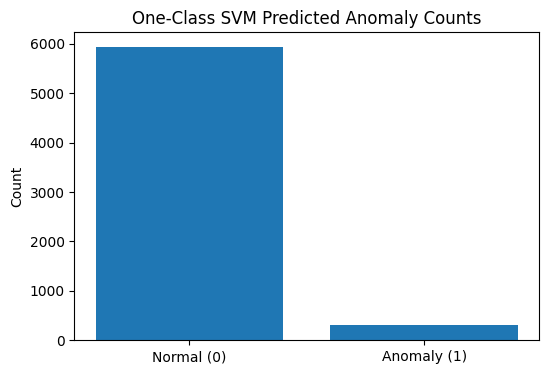

svm_anomaly
0    5934
1     310
Name: count, dtype: int64


In [78]:
counts = df_svm["svm_anomaly"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Normal (0)", "Anomaly (1)"], counts.values)
plt.title("One-Class SVM Predicted Anomaly Counts")
plt.ylabel("Count")
plt.show()

print(counts)

### Ground Truth vs One-Class SVM
Although the model is unsupervised, synthetic attack labels are used here for post hoc evaluation.

svm_anomaly     0    1
is_attack             
0            5650  224
1             284   86


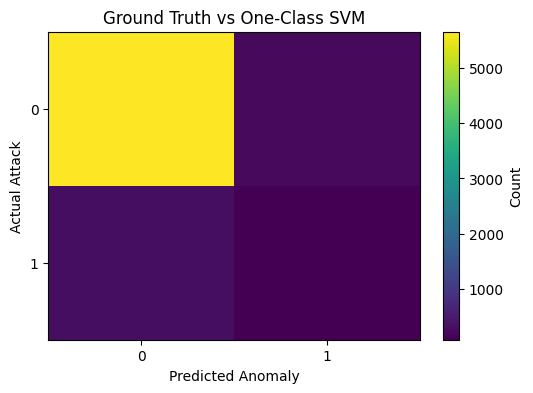

In [79]:
comparison = pd.crosstab(df_svm["is_attack"], df_svm["svm_anomaly"])
print(comparison)

plt.figure(figsize=(6,4))
plt.imshow(comparison, aspect="auto")
plt.title("Ground Truth vs One-Class SVM")
plt.xlabel("Predicted Anomaly")
plt.ylabel("Actual Attack")
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])
plt.colorbar(label="Count")
plt.show()

### One-Class SVM Score Distribution
The score distribution shows how observations are positioned relative to the learned boundary of normal behavior.

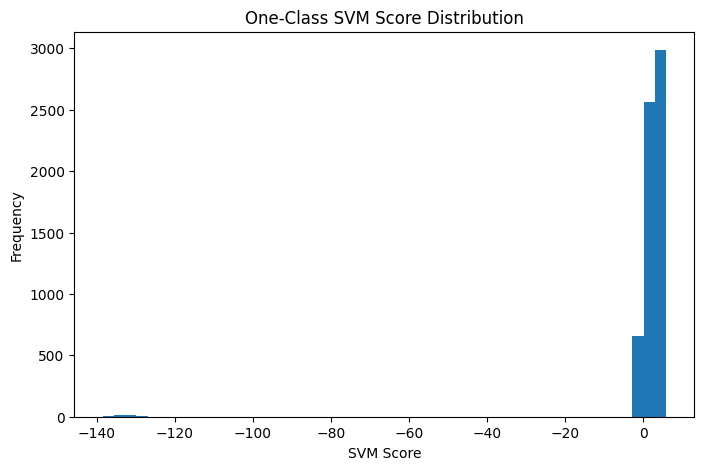

In [80]:
plt.figure(figsize=(8,5))
plt.hist(df_svm["svm_score"], bins=50)
plt.title("One-Class SVM Score Distribution")
plt.xlabel("SVM Score")
plt.ylabel("Frequency")
plt.show()

### Feature Space Visualization
This plot shows model predictions in feature space using `risk_score` and `session_duration_min`.

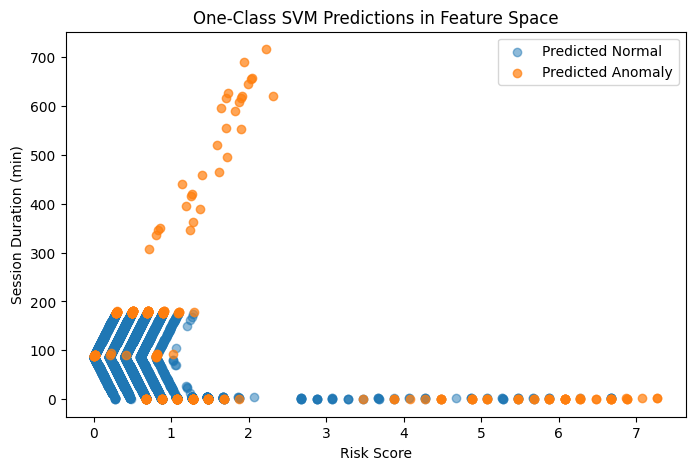

In [81]:
plt.figure(figsize=(8,5))

normal = df_svm[df_svm["svm_anomaly"] == 0]
anomaly = df_svm[df_svm["svm_anomaly"] == 1]

plt.scatter(
    normal["risk_score"],
    normal["session_duration_min"],
    alpha=0.5,
    label="Predicted Normal"
)

plt.scatter(
    anomaly["risk_score"],
    anomaly["session_duration_min"],
    alpha=0.7,
    label="Predicted Anomaly"
)

plt.title("One-Class SVM Predictions in Feature Space")
plt.xlabel("Risk Score")
plt.ylabel("Session Duration (min)")
plt.legend()
plt.show()

### Temporal Distribution of Predicted Anomalies
This visualization shows how One-Class SVM anomaly predictions are distributed across the dataset.

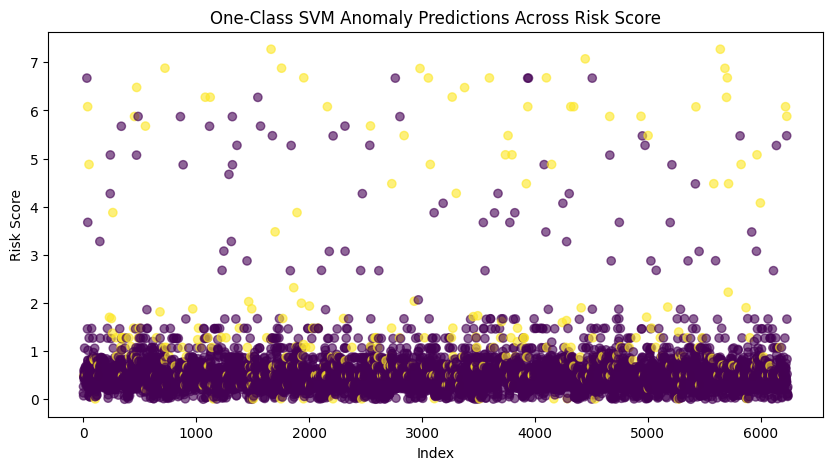

In [82]:
plt.figure(figsize=(10,5))

plt.scatter(
    df_svm.index,
    df_svm["risk_score"],
    c=df_svm["svm_anomaly"],
    alpha=0.6
)

plt.title("One-Class SVM Anomaly Predictions Across Risk Score")
plt.xlabel("Index")
plt.ylabel("Risk Score")
plt.show()

### Observations

- The One-Class SVM model classified 5934 records as normal and 310 records as anomalous.
- Comparison with ground truth shows that the model correctly detected 86 true attack records.
- However, 284 attack records were missed, indicating limited sensitivity to the full range of injected anomalies.
- The model also produced 224 false positives, showing that some normal records were incorrectly classified as anomalous.
- Compared with earlier models, One-Class SVM performs better than LOF but less effectively than Isolation Forest.
- The results suggest that the current feature space is more favorable to global outlier detection than to boundary-based separation.

### Interpretation

One-Class SVM provides a boundary-based perspective on anomaly detection by learning the region occupied by normal behavior and flagging points outside that region as anomalies. In this study, the model was able to identify some suspicious behavioral deviations, but it struggled to capture many injected attack records. This suggests that while the engineered features contain useful anomaly signals, the attack patterns in the dataset are not fully separable through a One-Class SVM boundary alone.

### Conclusion

The One-Class SVM model contributes an additional anomaly detection perspective to the pipeline, but its performance indicates that it is less suitable than Isolation Forest for the current dataset. The findings reinforce the importance of comparing multiple unsupervised models when evaluating behavioral anomaly detection in security logs.

## 11. Autoencoder Analysis

### Objective
To evaluate the effectiveness of an autoencoder-based anomaly detection model in identifying suspicious behavioral patterns within the synthetic enterprise security dataset.

### Method
The autoencoder was trained on the engineered numerical feature space to learn the structure of normal user behavior through reconstruction. After training, each record was assigned a reconstruction error, which was used as the anomaly score. Records with reconstruction errors above a selected threshold were classified as anomalous.

The model was applied to the following features:
- `risk_score`
- `session_duration_min`
- `login_freq_5`
- `failed_attempts_rolling`
- `session_zscore`
- `failed_zscore`

The model generated:
- `autoencoder_score`
- `autoencoder_anomaly`

### Autoencoder dataset output preview

In [90]:
df_auto.head()

,timestamp,user_id,username,department,role,privilege_level,source_ip,location,device_type,resource_accessed,...,failed_attempts_rolling,session_zscore,failed_zscore,session_deviation,risk_score,session_duration_min_zscore,login_freq_5_zscore,risk_score_zscore,autoencoder_score,autoencoder_anomaly
0,2026-01-01 09:05:41,U001,johnsonjoshua,HR,Analyst,low,10.5.48.47,New York,Windows-Laptop,email_portal,...,0.0,0.666859,-0.198587,46.931373,0.133372,0.666859,-1.492579,-0.656367,0.000116,0
1,2026-01-01 11:53:29,U001,johnsonjoshua,HR,Analyst,low,10.5.48.137,New York,Windows-Laptop,email_portal,...,0.0,1.326202,-0.198587,87.931373,0.265240,1.326202,-1.492579,-0.469247,0.000797,0
2,2026-01-01 12:17:27,U001,johnsonjoshua,HR,Analyst,low,10.5.48.87,New York,Windows-Laptop,git_server,...,0.0,0.361309,-0.198587,27.931373,0.072262,0.361309,-1.492579,-0.743081,0.000080,0
3,2026-01-01 12:41:04,U001,johnsonjoshua,HR,Analyst,low,10.5.48.11,New York,Windows-Laptop,git_server,...,0.0,1.438773,-0.198587,94.931373,0.487755,1.438773,-0.543820,-0.153502,0.000866,0
4,2026-01-01 12:53:01,U001,johnsonjoshua,HR,Analyst,low,10.5.48.33,New York,Windows-Laptop,hr_portal,...,0.0,-0.249789,-0.198587,-10.068627,0.449958,-0.249789,0.404940,-0.207135,0.000088,0


### Prediction Summary
This section shows the number of records classified as normal versus anomalous by the autoencoder model.

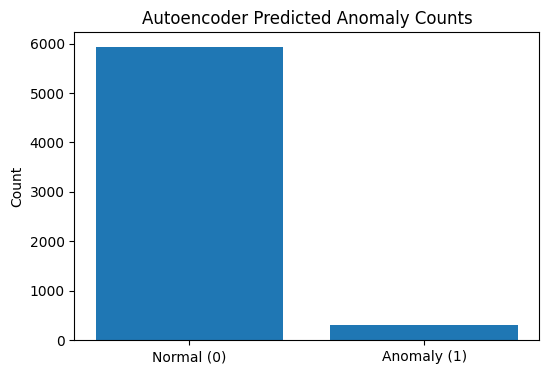

autoencoder_anomaly
0    5931
1     313
Name: count, dtype: int64


In [85]:
counts = df_auto["autoencoder_anomaly"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Normal (0)", "Anomaly (1)"], counts.values)
plt.title("Autoencoder Predicted Anomaly Counts")
plt.ylabel("Count")
plt.show()

print(counts)

autoencoder_anomaly     0    1
is_attack                     
0                    5757  117
1                     174  196


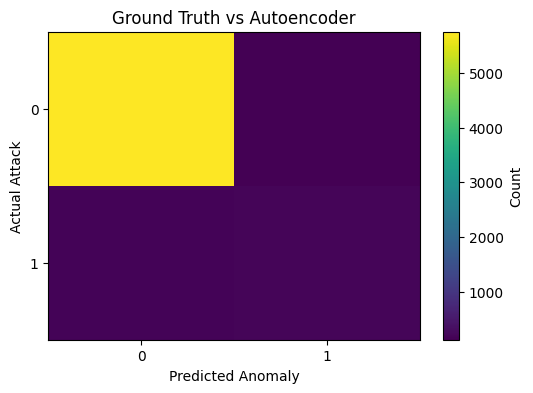

In [86]:
comparison = pd.crosstab(df_auto["is_attack"], df_auto["autoencoder_anomaly"])
print(comparison)

plt.figure(figsize=(6,4))
plt.imshow(comparison, aspect="auto")
plt.title("Ground Truth vs Autoencoder")
plt.xlabel("Predicted Anomaly")
plt.ylabel("Actual Attack")
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])
plt.colorbar(label="Count")
plt.show()

### Reconstruction Error Distribution
The reconstruction error distribution shows how strongly each record deviates from the learned structure of normal behavior. Higher values indicate a greater likelihood of anomaly.

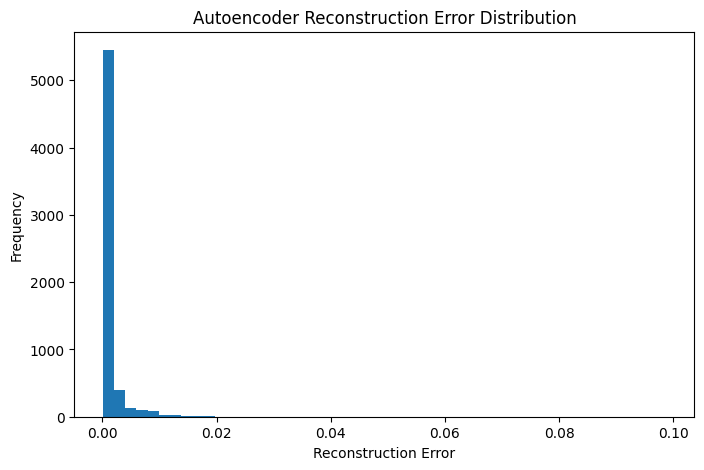

In [87]:
plt.figure(figsize=(8,5))
plt.hist(df_auto["autoencoder_score"], bins=50)
plt.title("Autoencoder Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()

### Feature Space Visualization
This plot shows autoencoder predictions in feature space using `risk_score` and `session_duration_min`.

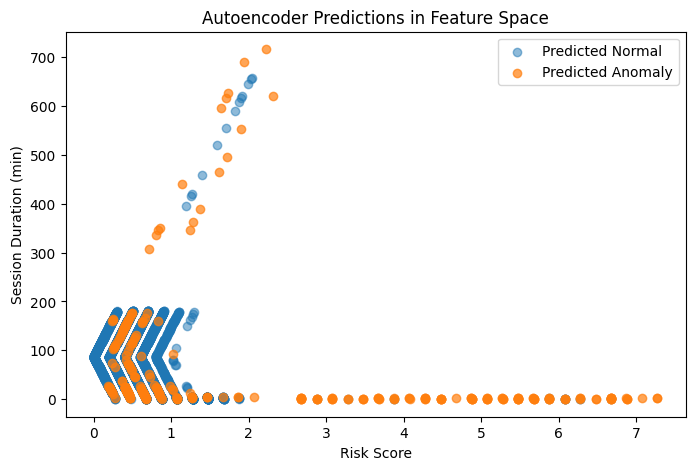

In [88]:
plt.figure(figsize=(8,5))

normal = df_auto[df_auto["autoencoder_anomaly"] == 0]
anomaly = df_auto[df_auto["autoencoder_anomaly"] == 1]

plt.scatter(
    normal["risk_score"],
    normal["session_duration_min"],
    alpha=0.5,
    label="Predicted Normal"
)

plt.scatter(
    anomaly["risk_score"],
    anomaly["session_duration_min"],
    alpha=0.7,
    label="Predicted Anomaly"
)

plt.title("Autoencoder Predictions in Feature Space")
plt.xlabel("Risk Score")
plt.ylabel("Session Duration (min)")
plt.legend()
plt.show()

### Temporal Distribution of Predicted Anomalies
This visualization shows how autoencoder anomaly predictions are distributed across the dataset.

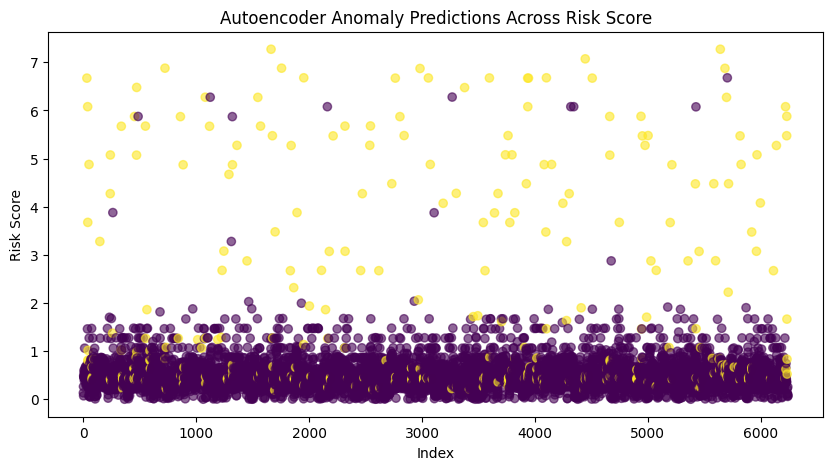

In [89]:
plt.figure(figsize=(10,5))

plt.scatter(
    df_auto.index,
    df_auto["risk_score"],
    c=df_auto["autoencoder_anomaly"],
    alpha=0.6
)

plt.title("Autoencoder Anomaly Predictions Across Risk Score")
plt.xlabel("Index")
plt.ylabel("Risk Score")
plt.show()

### Observations

- The autoencoder classified 5931 records as normal and 313 records as anomalous.
- Comparison with ground truth shows that the model correctly detected 196 true attack records.
- Only 117 normal records were incorrectly flagged as anomalous, indicating a relatively low false positive rate.
- The model missed 174 attack records, which is still significant, but lower than the number missed by the previous models.
- Training loss decreased steadily from 0.974234 at the first epoch to 0.001260 by epoch 50, indicating successful learning of the normal behavioral structure.
- The reconstruction error threshold of 0.005230 was used to separate normal and anomalous observations.

### Interpretation

The autoencoder achieved the strongest performance among the models tested so far. Its ability to learn compressed representations of normal behavior and detect abnormal reconstruction patterns makes it well suited for this dataset. The results suggest that the engineered features capture enough behavioral structure for deep learning to distinguish normal and malicious activity more effectively than the classical unsupervised models.

### Conclusion

The autoencoder provides the best anomaly detection performance so far in the study, outperforming Isolation Forest, Local Outlier Factor, and One-Class SVM in terms of attack detection and false positive control. This indicates that deep learning-based reconstruction methods are highly promising for behavioral anomaly detection in synthetic enterprise security logs.